project 1 in fuel cells. loading experimental data, fitting polarization, and then doing economic analysis. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd

$V_{\text{cell}}(I) = E_{\mathrm{eq}}-\frac{R_u T}{\alpha_c F}\ln\left(\frac{I+I_{XO}}{I_0}\right) - \frac{R_u T}{nF}\ln\left(\frac{I_{L}}{I_{L}-(I+I_{XO})}\right)-IR_{\text{total}}$

In [2]:
E_EQ = 1.136 # V, equilibrium potential for H2/O2 at 353K
R_U = 8.314  # J/(mol*K)
ALPHA_C = 1.0
FARADAY = 96485.0 # coulombs/mol
T = 353.15  #K

def v_model(params, current, n = 2):
	"""
	 --- SAME AS PROVIDED MATLAB CODE --- 
	params[0] ; I_0     : Reference exchange current density (A/m^2)
	params[1] ; I_lim   : Limiting current density (A/m^2)
	params[2] ; R_total : Total resistance (ohm*m^2)
	params[3] ; I_xo    : Cross-over current density (A/m^2)
	"""
	i0, i_lim, r_total, i_xo = params
	i_eff = current + i_xo

	return (
		E_EQ
		- (R_U * T) / (ALPHA_C * FARADAY) * np.log(i_eff / i0)
		- (R_U * T) / (n * FARADAY) * np.log(i_lim /(i_lim - i_eff))   # changed + to - ; changed n=4 to n=2
		- current * r_total
	)


def objective(params, i_exp, v_exp):
	i0, i_lim, r_total, i_xo = params
	i_eff = i_exp + i_xo
	# if i0 <= 0 or i_lim <= 0 or r_total < 0 or np.any(i_eff <= 0) or np.any(i_eff >= i_lim):
	# 	return 1e12  # penalize non-physics params

	residual = v_model(params, i_exp) - v_exp
	return np.linalg.norm(residual)

loading in the experimental data from excel

In [3]:
df = pd.read_excel("data.xlsx", sheet_name="data", usecols="A:B")
v_exp = df.iloc[:, 0].to_numpy(dtype=float)  # Volts
i_exp = df.iloc[:, 1].to_numpy(dtype=float)  # mA/cm^2

In [4]:
# Initial guess: [I_0, I_lim, R_total, I_xo]
a0 = np.array([0.05, 12200.0, 2.5e-5, 30.0], dtype=float)

result = minimize(objective, a0, args=(i_exp, v_exp), method="Nelder-Mead")
if not result.success:
    raise RuntimeError(f"Optimization failed: {result.message}")

a_hat = result.x
print(f"Best-fit parameters \n I_0 {a_hat[0]},\n I_lim {a_hat[1]},\n R_total {a_hat[2]},\n I_xo {a_hat[3]}]")

i_range = np.arange(i_exp.min(), i_exp.max() + 1.0, 1.0)
v_fit = v_model(a_hat, i_range)

Best-fit parameters 
 I_0 0.002523059864441392,
 I_lim 1200.1794561440906,
 R_total 6.338882439813228e-05,
 I_xo 0.17887332001422795]


C:\Users\momun\AppData\Local\Temp\ipykernel_7512\727610298.py:20: RuntimeWarning: invalid value encountered in log
  - (R_U * T) / (ALPHA_C * FARADAY) * np.log(i_eff / i0)
C:\Users\momun\AppData\Local\Temp\ipykernel_7512\727610298.py:21: RuntimeWarning: invalid value encountered in log
  - (R_U * T) / (n * FARADAY) * np.log(i_lim /(i_lim - i_eff))   # changed + to - ; changed n=4 to n=2


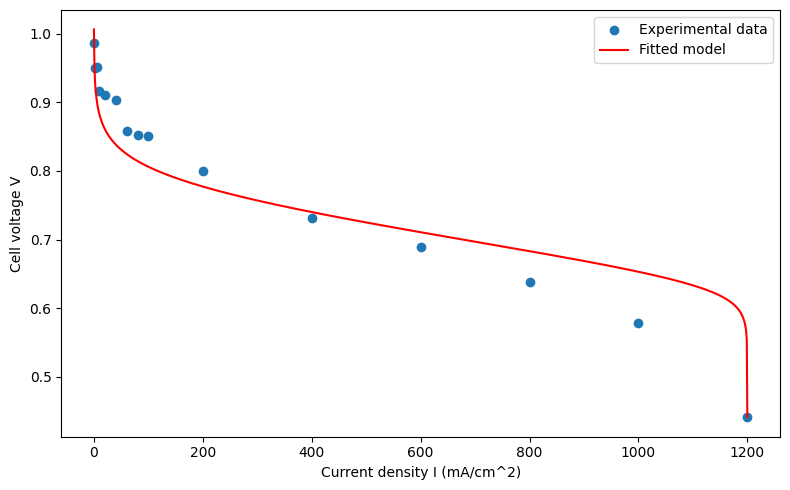

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(i_exp, v_exp, label="Experimental data")
plt.plot(i_range, v_fit, "r", label="Fitted model")
plt.xlabel("Current density I (mA/cm^2)")
plt.ylabel("Cell voltage V")
plt.legend()
plt.tight_layout()
plt.show()